In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend ,resample
from statsmodels.tsa.ar_model import AutoReg
from scipy.signal import find_peaks
from scipy.integrate import simpson
from scipy.signal import periodogram
import pywt
import os
import re


# 1. Read files and make CSV

In [2]:
import pandas as pd
import os
import re

# Configuration: File paths and directory settings
input_folder = '3-class' 
output_csv = 'EOG_dataset.csv'

# Mapping dictionary for dataset classes
class_mapping = {
    'yukari': 'Up',
    'asagi': 'Down',
    'sag': 'Right',
    'sol': 'Left',
    'kirp': 'Blink'
}

def process_eog_with_trial_numbers():
    all_trials = []
    
    # Check if the source directory exists
    if not os.path.exists(input_folder):
        print(f"Error: The path '{input_folder}' does not exist!")
        return

    # List all .txt files in the directory
    files = [f for f in os.listdir(input_folder) if f.endswith('.txt')]
    
    for filename in files:
        lower_filename = filename.lower()
        
        # 1. Identify the Label and ignore files that don't match our classes
        label = None
        current_key = ""
        for key, val in class_mapping.items():
            if key in lower_filename:
                label = val
                current_key = key
                break
        
        # Skip the file if no matching class is found
        if label is None:
            continue 

        # 2. Extract the Trial Number using Regular Expressions
        # Searches for digits directly following the class keyword
        trial_number = "Unknown"
        match = re.search(rf"{current_key}(\d+)", lower_filename)
        if match:
            trial_number = match.group(1)

        # 3. Determine the Channel type (Horizontal or Vertical)
        if 'h.txt' in lower_filename:
            channel = 'H'
        elif 'v.txt' in lower_filename:
            channel = 'V'
        else:
            channel = 'Other'

        # 4. Read the signal values from the file
        file_path = os.path.join(input_folder, filename)
        try:
            with open(file_path, 'r') as f:
                # Convert each line to an integer and store in a list
                signal_values = [int(line.strip()) for line in f if line.strip()]
            
            # 5. Organize data into a flat row structure
            trial_data = {
                'Trial_ID': filename.replace('.txt', ''),
                'Trial_Number': trial_number,
                'Label': label,
                'Channel': channel
            }
            
            # Add each signal point as a new column (Point_0, Point_1, etc.)
            for i, val in enumerate(signal_values):
                trial_data[f'Point_{i}'] = val
            
            all_trials.append(trial_data)

        except Exception as e:
            print(f"Error reading {filename}: {e}")

    # 6. Save the aggregated data to a CSV file
    if all_trials:
        df = pd.DataFrame(all_trials)
        
        # Reorder columns to ensure metadata comes before signal points
        metadata_cols = ['Trial_ID', 'Trial_Number', 'Label', 'Channel']
        point_cols = sorted([c for c in df.columns if c.startswith('Point_')], 
                            key=lambda x: int(x.split('_')[1]))
        
        df = df[metadata_cols + point_cols]
        
        df.to_csv(output_csv, index=False)
        print("File saved successfully!")
        print(f"Data Shape: {df.shape[0]} rows (trials) and {df.shape[1]} columns.")
    else:
        print("No matching files found to process.")


In [3]:
process_eog_with_trial_numbers()

File saved successfully!
Data Shape: 202 rows (trials) and 255 columns.


# 2. Read CSV file

In [18]:
data_path = 'EOG_dataset.csv'

In [19]:
import pandas as pd
import numpy as np

def load_csv_to_paired_dictionary(csv_path):
    # 1. Read the CSV file
    df = pd.read_csv(csv_path)
    
    # 2. Fill missing values with 0 (important for varying signal lengths)
    df = df.fillna(0)
    
    # 3. Create the dictionary to hold the results
    current_data = {}
    
    # 4. Group data by 'Trial_Number' and 'Label' to pair H and V rows
    grouped = df.groupby(['Trial_Number', 'Label'])
    
    for (trial_num, label), group in grouped:
        # Get all columns that start with 'Point_'
        signal_cols = [c for c in df.columns if c.startswith('Point_')]
        
        # Extract Horizontal (H) and Vertical (V) data for this specific trial
        h_row = group[group['Channel'] == 'H']
        v_row = group[group['Channel'] == 'V']
        
        # Convert the row values into a 1D Numpy array
        # We use .iloc[0] because we expect only one H and one V per trial
        if not h_row.empty and not v_row.empty:
            h_sig = h_row[signal_cols].values.flatten()
            v_sig = v_row[signal_cols].values.flatten()
            
            # Use the label as the dictionary key (or f"{label}_{trial_num}" for uniqueness)
            dict_key = f"{label}_{trial_num}"
            current_data[dict_key] = [h_sig, v_sig]
            
    return current_data

# --- Usage ---
csv_file = 'EOG_dataset.csv'
current_data = load_csv_to_paired_dictionary(csv_file)

# --- Test Output ---
if current_data:
    sample_key = list(current_data.keys())[0]
    print(f"Loaded {len(current_data)} paired trials.")
    print(f"Example Key: {sample_key}")
    print(f"H-Signal shape: {current_data[sample_key][0].shape}")
    print(f"V-Signal shape: {current_data[sample_key][1].shape}")

Loaded 100 paired trials.
Example Key: Blink_1
H-Signal shape: (251,)
V-Signal shape: (251,)


In [20]:
current_data

{'Blink_1': [array([140, 135, 135, 143, 138, 134, 141, 140, 135, 140, 139, 133, 135,
         139, 137, 129, 135, 137, 132, 136, 139, 135, 134, 137, 133, 131,
         134, 137, 125, 134, 135, 129, 129, 137, 129, 127, 134, 134, 127,
         130, 133, 125, 131, 136, 130, 127, 135, 132, 128, 132, 133, 125,
         131, 133, 124, 126, 133, 130, 126, 132, 133, 125, 130, 131, 124,
         126, 129, 128, 122, 130, 129, 123, 127, 132, 120, 126, 128, 124,
         122, 127, 124, 120, 130, 137, 145, 162, 170, 168, 157, 158, 151,
         140, 142, 142, 134, 137, 136, 130, 129, 134, 131, 126, 130, 130,
         120, 124, 128, 124, 122, 130, 126, 121, 128, 127, 120, 126, 126,
         121, 123, 127, 124, 121, 127, 126, 119, 125, 126, 120, 123, 126,
         124, 118, 125, 125, 118, 124, 124, 118, 120, 125, 121, 116, 124,
         125, 117, 123, 124, 119, 120, 125, 119, 120, 125, 123, 117, 125,
         124, 119, 122, 128, 120, 119, 125, 125, 119, 123, 124, 118, 120,
         125, 119, 120, 128

# 3. Plot signal

In [21]:
def plot_single_trial_eog(h_signal, v_signal, title="EOG Signal"):
    # Create a figure with 2 subplots sharing the same X-axis
    fig, (ax_h, ax_v) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    
    # 1. Plot Horizontal Signal (Top)
    ax_h.plot(h_signal, color='#1f77b4', linewidth=1.5, label='Horizontal (H)')
    ax_h.set_title(title, fontsize=12, fontweight='bold')
    ax_h.set_ylabel("Amplitude")
    ax_h.legend(loc="upper right")
    ax_h.grid(True, linestyle='--', alpha=0.6)
    
    # 2. Plot Vertical Signal (Bottom)
    ax_v.plot(v_signal, color='#d62728', linewidth=1.5, label='Vertical (V)')
    ax_v.set_ylabel("Amplitude")
    ax_v.set_xlabel("Sample Points")
    ax_v.legend(loc="upper right")
    ax_v.grid(True, linestyle='--', alpha=0.6)
    
    # Adjust spacing to prevent overlapping
    plt.tight_layout()
    plt.show()


def plot_complex_grid(data_dict, rows=20, cols=5):
    trial_keys = list(data_dict.keys())
    total_plots = rows * cols
    
    # Create a large figure
    # Width = 4 units per column, Height = 3 units per row
    fig = plt.figure(figsize=(cols * 4, rows * 3))
    
    for i in range(min(total_plots, len(trial_keys))):
        key = trial_keys[i]
        h_signal = data_dict[key][0]
        v_signal = data_dict[key][1]
        
        # Calculate position for the H signal (Top part of the cell)
        # We use a grid of (rows*2) to stack H and V
        ax_h = plt.subplot(rows * 2, cols, i + 1 + (i // cols) * cols)
        ax_h.plot(h_signal, color='blue', linewidth=0.7)
        ax_h.set_title(f"Trial: {key}", fontsize=8)
        ax_h.tick_params(axis='both', which='both', labelsize=7)
        ax_h.grid(True, alpha=0.2)
        
        # Calculate position for the V signal (Bottom part of the cell)
        ax_v = plt.subplot(rows * 2, cols, i + 1 + (i // cols + 1) * cols)
        ax_v.plot(v_signal, color='red', linewidth=0.7)
        ax_v.tick_params(axis='both', which='both', labelsize=7)
        ax_v.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

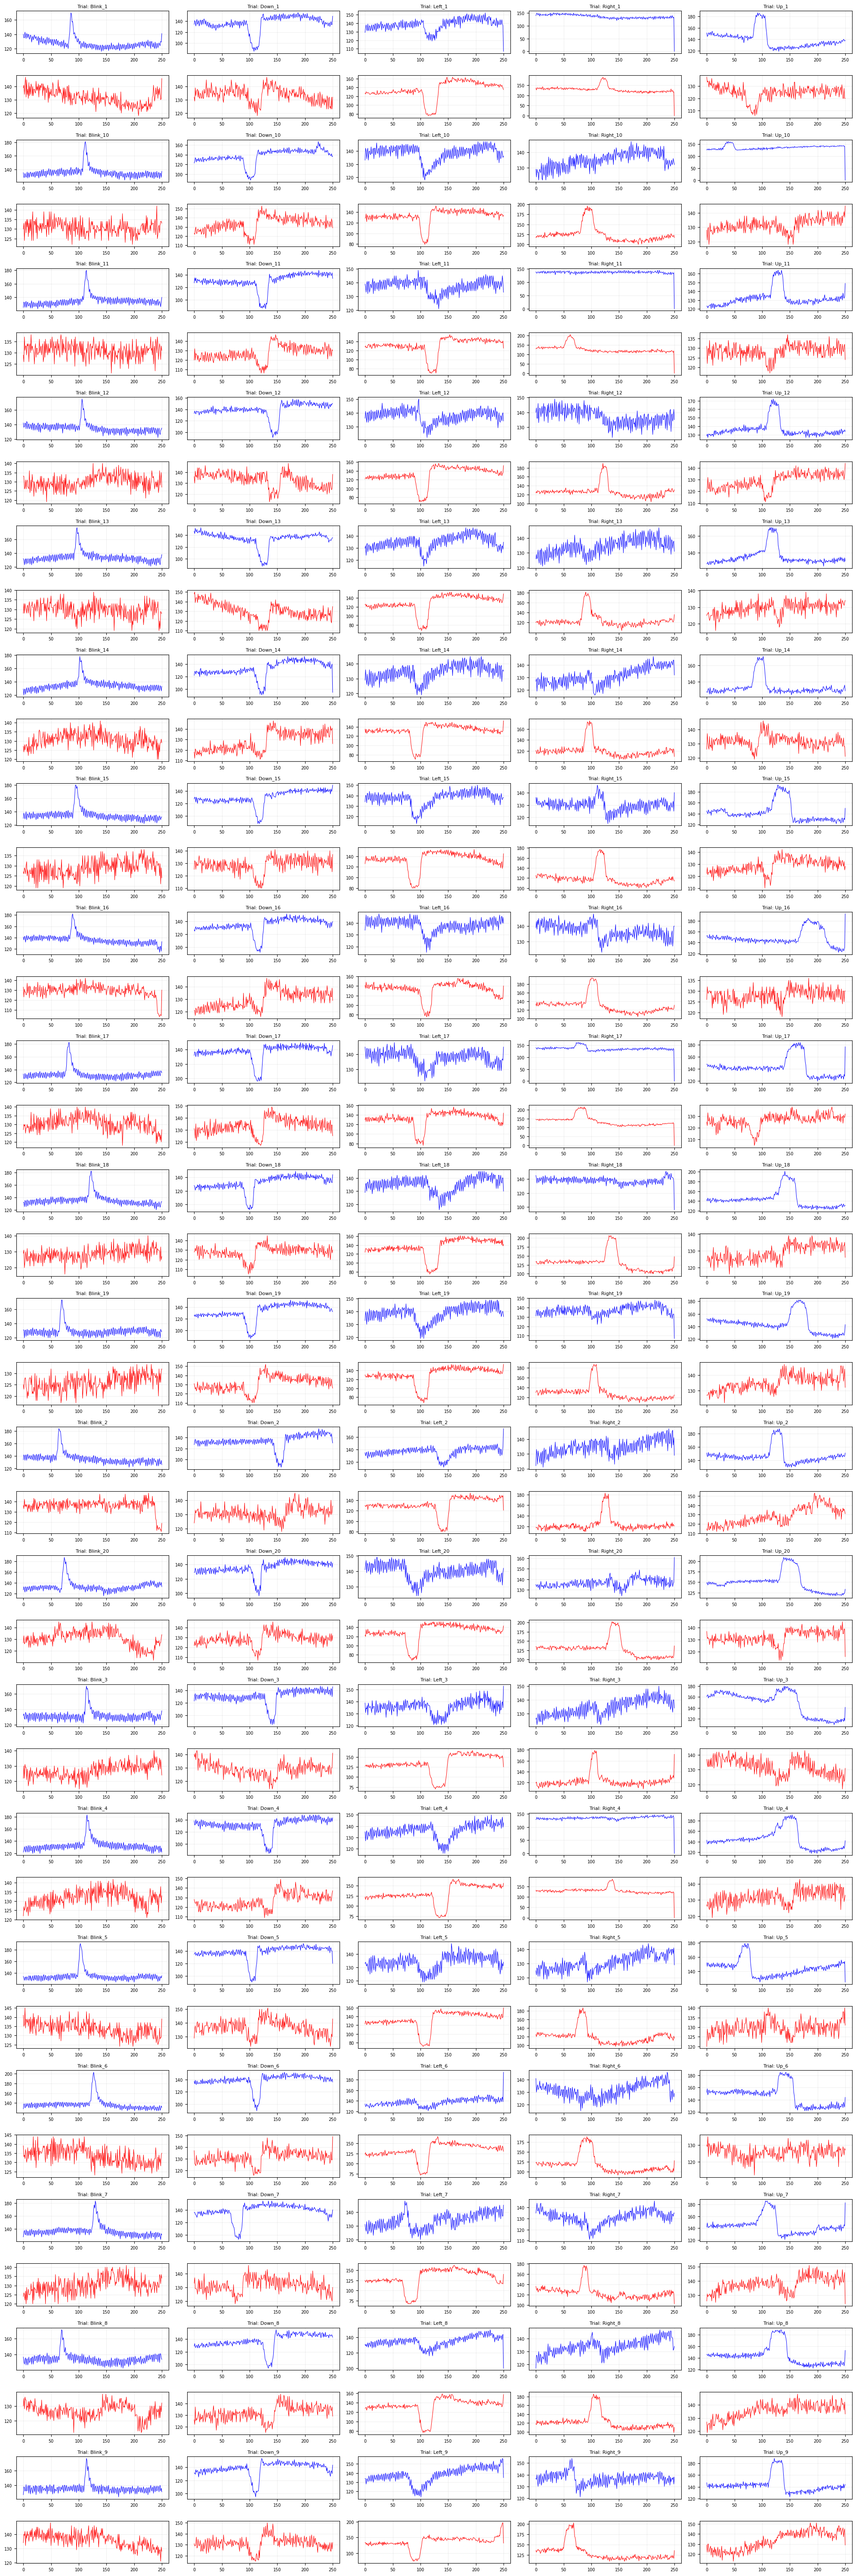

In [22]:
plot_complex_grid(current_data, rows=20, cols=5)

# 4. preprocessing

In [23]:
def butter_bandpass_filter(Input_Signal,Low_cutoff,High_Cutoff,Sampling_Rate,order):
    nyq=0.5*Sampling_Rate
    low=Low_cutoff/nyq
    high=High_Cutoff/nyq
    Numeator,denminator = butter(order,[low,high],btype='band',output='ba',analog=False,fs=None)
    filtered=filtfilt(Numeator,denminator,Input_Signal)
    return filtered

In [25]:
preprocess_signal = {}
for label in current_data:
    preprocess_signal[label] = [butter_bandpass_filter(sig,Low_cutoff=0.5,High_Cutoff=20,Sampling_Rate=176,order=2) for sig in current_data[label]]

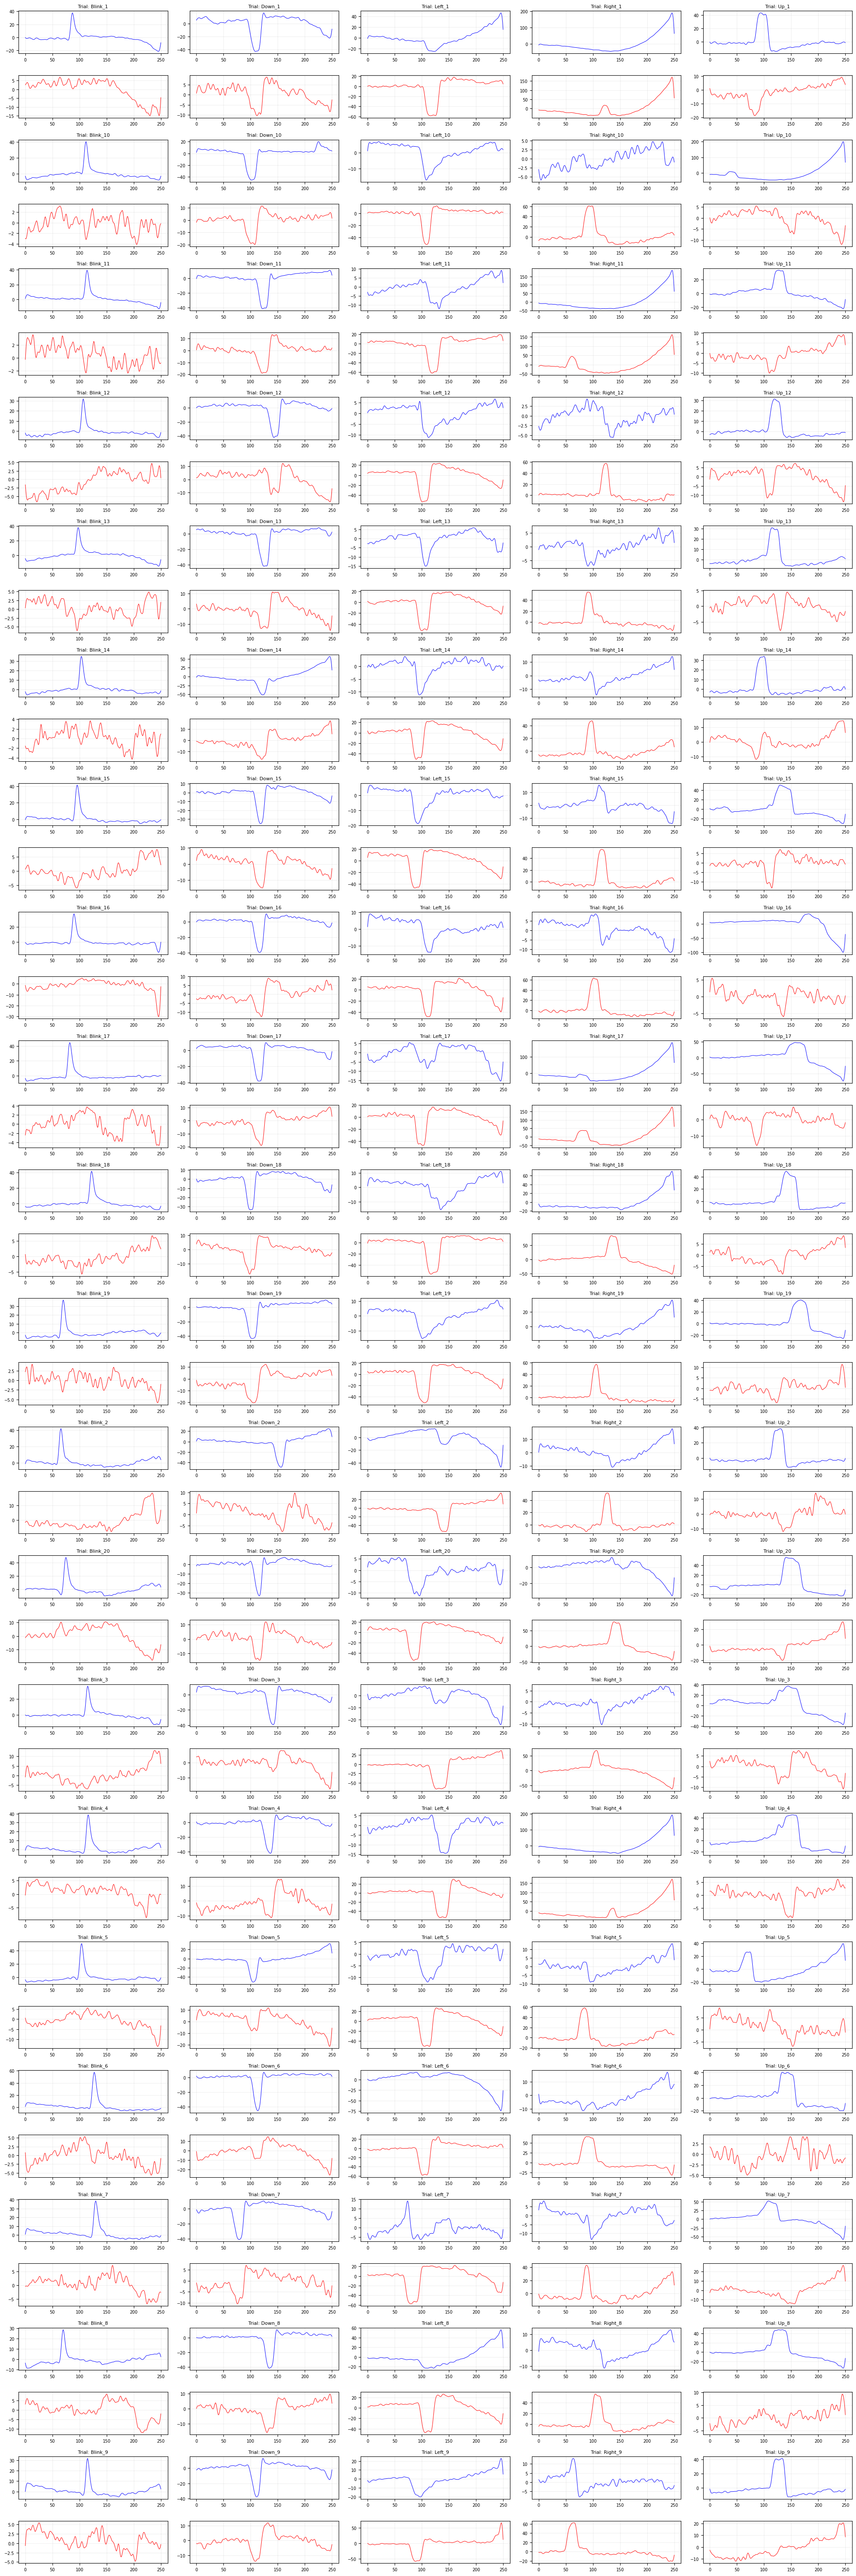

In [26]:
plot_complex_grid(preprocess_signal, rows=20, cols=5)

# 5. Raw Features

In [27]:
# Raw Features 
X_raw = preprocess_signal

# Feature Extraction

In [ ]:
def extract_mix_features(signal):
    """
    Extracts a combination of Morphological and Statistical features 
    from the time domain signal.
    """
    # --- Morphological Features ---
    peaks, _ = find_peaks(signal)
    if len(peaks) > 0:
        max_peak = np.max(signal[peaks])
    else:
        max_peak = np.max(signal)
        
    # Calculate Area Under the Curve (AUC) using Simpson's rule
    area = simpson(signal)
    
    # --- Statistical Features ---
    mu = np.mean(signal)
    # Calculate the variance (measure of signal spread)
    var = np.var(signal)
    std = np.std(signal)
    
    return [max_peak, area, mu, var, std]

In [ ]:
def extract_wavelet_features(signal):
    """
    Fs = 176 Hz, Level = 2.
    Extracts cA2 coefficients covering the 0-22 Hz range.
    """
    coeffs = pywt.wavedec(signal, 'db1', level=2)
    wavelet_features = coeffs[0]
    
    return wavelet_features

In [ ]:
def extract_ar_features(signal, lags=10):
    from scipy.signal import detrend
    import numpy as np
    from statsmodels.tsa.ar_model import AutoReg
    
    # preprocess
    signal = detrend(signal)
    std = np.std(signal)
    
    # avoid division by zero
    if std == 0:
        return np.zeros(lags + 1)
    
    signal = (signal - np.mean(signal)) / std
    
    # AR model
    model = AutoReg(signal, lags=lags).fit()
    
    # coefficients فقط
    coeffs = model.params[1:]
    
    return coeffs

In [ ]:
def extract_psd_features(signal, fs=176):
    """
    Computes the Power Spectral Density (PSD) using the Periodogram method.
    Returns the power values for each frequency.
    """
    f, Pxx = periodogram(signal, fs, scaling='density')
    relevant_indices = np.where(f <= 40)[0]
    psd_features = Pxx[relevant_indices]
    
    return psd_features

In [ ]:
def extract_ar_features2(signal, lags=10):
    from scipy.signal import detrend
    import numpy as np
    from statsmodels.tsa.ar_model import AutoReg
    
    signal = detrend(signal)
    std = np.std(signal)
    
    if std == 0:
        return np.zeros(lags)
    
    signal = (signal - np.mean(signal)) / std
    
    model = AutoReg(signal, lags=lags).fit()
    
    return model.params  

In [ ]:
def prepare_data_for_svm(raw_signals_H, raw_signals_V, signals_H, signals_V):
    # Lists to store the final feature matrices
    X_wavelet = []
    X_ar = []
    X_mix = []
    X_psd = []

    # Loop through each of the 100 trials
    for i in range(len(signals_H)):
        h_sig = signals_H[i]
        v_sig = signals_V[i]
        h_raw = raw_signals_H[i]
        v_raw = raw_signals_V[i]
        
        # --- 1. Wavelet Path (Raw Bandwidth-Focused) ---
        feat_h_wav = extract_wavelet_features(h_raw)
        feat_v_wav = extract_wavelet_features(v_raw)
        X_wavelet.append(np.concatenate([feat_h_wav, feat_v_wav]))
        
        # --- 2. AR Coefficients Path ---
        feat_h_ar = extract_ar_features2(h_sig)
        feat_v_ar = extract_ar_features2(v_sig)
        X_ar.append(np.concatenate([feat_h_ar, feat_v_ar]))
        
        # --- 3. Mix (Statistical & Morphological) Path ---
        feat_h_mix = extract_mix_features(h_sig)
        feat_v_mix = extract_mix_features(v_sig)
        X_mix.append(np.concatenate([feat_h_mix, feat_v_mix]))

        # --- 4. PSD (Frequency Domain) Path ---
        feat_h_psd = extract_psd_features(h_sig)
        feat_v_psd = extract_psd_features(v_sig)
        X_psd.append(np.concatenate([feat_h_psd, feat_v_psd]))

    # Convert everything to numpy arrays for the SVM
    return (np.array(X_wavelet), 
            np.array(X_ar), 
            np.array(X_mix), 
            np.array(X_psd))


In [ ]:
X_wav, X_ar, X_mix, X_psd = prepare_data_for_svm(raw_signals_H, raw_signals_V, signals_H, signals_V)
print(f"Wavelet Matrix Shape: {X_wav.shape}") 
print(f"AR Matrix Shape:      {X_ar.shape}")  
print(f"Mix Matrix Shape:     {X_mix.shape}") 
print(f"PSD Matrix Shape:     {X_psd.shape}") 


# Apply SVM Classification for each feature

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ========= Prepare Data =========
X_raw = np.concatenate([signals_H, signals_V], axis=1)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

X_train_ar, X_test_ar, _, _ = train_test_split(
    X_ar, y, test_size=0.2, random_state=42, stratify=y
)

X_train_wav, X_test_wav, _, _ = train_test_split(
    X_wav, y, test_size=0.2, random_state=42, stratify=y
)

X_train_psd, X_test_psd, _, _ = train_test_split(
    X_psd, y, test_size=0.2, random_state=42, stratify=y
)

X_train_mix, X_test_mix, _, _ = train_test_split(
    X_mix, y, test_size=0.2, random_state=42, stratify=y
)

# ========= OvO Model =========
def train_and_evaluate_ovo(X_train, X_test, name):
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', decision_function_shape='ovo', C=1, gamma='scale')
    )

    # Train
    model.fit(X_train, y_train)

    # Test
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Cross Validation
    cv_score = cross_val_score(model, X_train, y_train, cv=5).mean()

    print(f"{name} -> Test Accuracy: {acc*100:.2f}% | CV: {cv_score*100:.2f}%")

    return acc

# ========= Run All Features =========
accuracies = {}

accuracies["Raw"] = train_and_evaluate_ovo(X_train_raw, X_test_raw, "Raw Data")
accuracies["AR"] = train_and_evaluate_ovo(X_train_ar, X_test_ar, "AR")
accuracies["Wavelet"] = train_and_evaluate_ovo(X_train_wav, X_test_wav, "Wavelet")
accuracies["PSD"] = train_and_evaluate_ovo(X_train_psd, X_test_psd, "PSD")
accuracies["Mix"] = train_and_evaluate_ovo(X_train_mix, X_test_mix, "Mix")

# ========= Best Feature =========
best_feature = max(accuracies, key=accuracies.get)
print(f"\n🔥 Best Feature using OvO SVM: {best_feature} ({accuracies[best_feature]*100:.2f}%)")